# TEC Data From Madrigal Database

This notebook contains analysis on the total electron content (TEC) data collected during the 2024 solar storm occuring over May 10th and 11th. TEC, measured in electrons per square meter, has the ability to impact radio wave transmissions. It is calculated through a dual frequency reciever by measuring the delay between frquencies. More electrons along the path of a radio wave between its transmitter and reciever will have a greater overall impact on the radio's signal. Sometimes, with especially high TEC values, radio waves can be refracted and scattered leading to radio blackouts. Additionally, high TEC values can disrupt global possitioning systems like GPS. Learn more about TEC [here](https://www.swpc.noaa.gov/phenomena/total-electron-content).

Solar weather increases TEC content in the ionosphere. The graphs produced in this notebook clearly demonstrate the 2024 May storm's on TEC content in the atmosphere. This data was aquired through the [Madrigal Database](http://millstonehill.haystack.mit.edu/) from Millstone Hill. It is formated in at NetCDF file, so the xarray and matplotlib packages were used to process the data.

In [14]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy
import hvplot
import hvplot.xarray

In [29]:
# loading datasets
ds_9th = xr.load_dataset('../data/TEC_geospatial_data/gps240509g.002.nc')
# converting the timestamps variable to normal date times
new_datetime = np.array(ds_9th.timestamps.values.astype(np.int64), dtype='datetime64[s]')
ds_9th['timestamps'] = new_datetime
# renaming the timestamps variable to time
ds_9th = ds_9th.rename({'timestamps': 'time'})

ds_10th = xr.load_dataset('../data/TEC_geospatial_data/gps240510g.003.nc')
new_datetime = np.array(ds_10th.timestamps.values.astype(np.int64), dtype='datetime64[s]')
ds_10th['timestamps'] = new_datetime
ds_10th = ds_10th.rename({'timestamps': 'time'})

ds_11th = xr.load_dataset('../data/TEC_geospatial_data/gps240511g.003.nc')
new_datetime = np.array(ds_11th.timestamps.values.astype(np.int64), dtype='datetime64[s]')
ds_11th['timestamps'] = new_datetime
ds_11th = ds_11th.rename({'timestamps': 'time'})

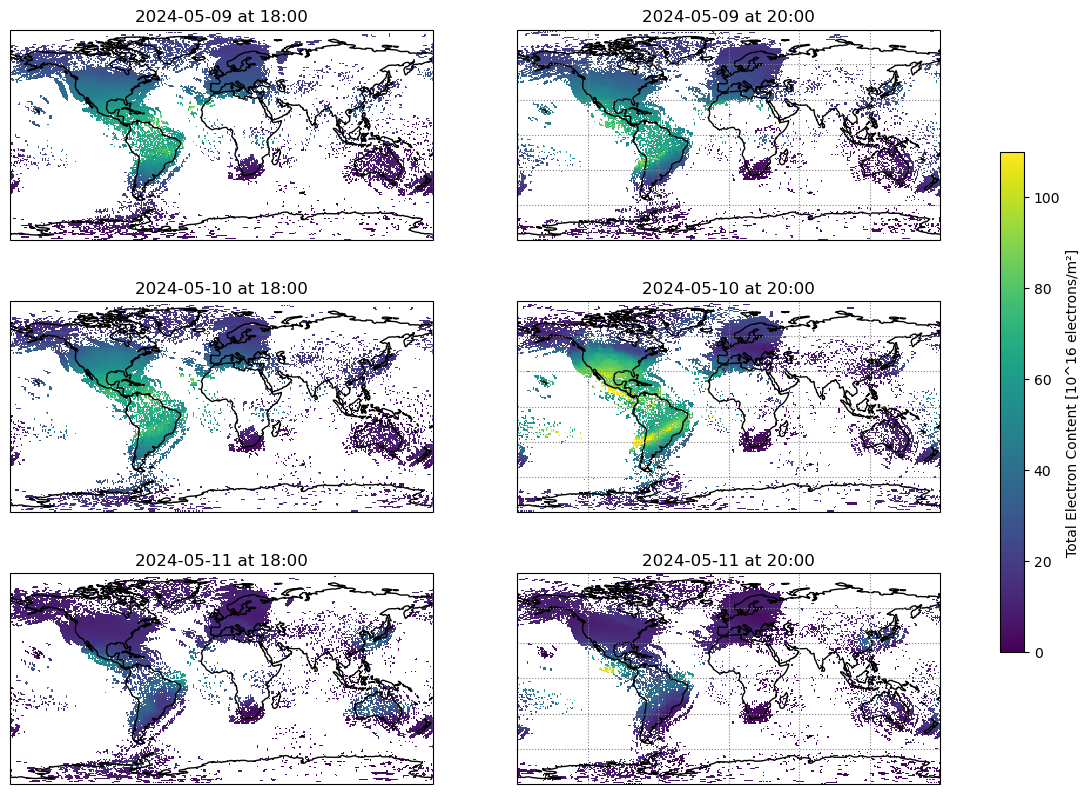

In [98]:
date1 = '2024-05-09'
date2 = '2024-05-10'
date3 = '2024-05-11'
time1 = '18:00'
time2 = '20:00'

fig, ax = plt.subplots(3,2, figsize=(12,10), subplot_kw={'projection': ccrs.PlateCarree()})
[ax1, ax2], [ax3, ax4], [ax5, ax6] = ax

# MAY 9th
ax1.coastlines()
cs = ax1.pcolormesh(ds_9th.tec.sel(time=f'{date1}T{time1}:00').glon, 
               ds_9th.tec.sel(time=f'{date1}T{time1}:00').gdlat, 
               ds_9th.tec.sel(time=f'{date1}T{time1}:00').values,
                vmin=0, vmax=110,
               transform=ccrs.PlateCarree())
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
#ax1.text(105, 80, f'{date1} at {time1}', bbox=text_box)
#gl = ax1.gridlines(draw_labels=True, linestyle=':', color='grey')
#gl.ylabels_left = False
ax1.set_title(f'{date1} at {time1}')

ax2.coastlines()
cs = ax2.pcolormesh(ds_9th.tec.sel(time=f'{date1}T{time2}:00').glon, 
               ds_9th.tec.sel(time=f'{date1}T{time2}:00').gdlat, 
               ds_9th.tec.sel(time=f'{date1}T{time2}:00').values,
                vmin=0, vmax=110,
               transform=ccrs.PlateCarree())
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
#ax1.text(105, 80, f'{date} at {time}', bbox=text_box)
ax2.gridlines(draw_labels=False, linestyle=':', color='grey')
ax2.set_title(f'{date1} at {time2}')


# MAY 10th
ax3.coastlines()
cs = ax3.pcolormesh(ds_10th.tec.sel(time=f'{date2}T{time1}:00').glon, 
               ds_10th.tec.sel(time=f'{date2}T{time1}:00').gdlat, 
               ds_10th.tec.sel(time=f'{date2}T{time1}:00').values,
                vmin=0, vmax=110,
               transform=ccrs.PlateCarree())
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
#ax3.text(105, 80, f'{date2} at {time1}', bbox=text_box)
#gl = ax1.gridlines(draw_labels=True, linestyle=':', color='grey')
#gl.ylabels_left = False
ax3.set_title(f'{date2} at {time1}')

ax4.coastlines()
cs = ax4.pcolormesh(ds_10th.tec.sel(time=f'{date2}T{time2}:00').glon, 
               ds_10th.tec.sel(time=f'{date2}T{time2}:00').gdlat, 
               ds_10th.tec.sel(time=f'{date2}T{time2}:00').values,
                vmin=0, vmax=110,
               transform=ccrs.PlateCarree())
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
#ax1.text(105, 80, f'{date} at {time}', bbox=text_box)
ax4.gridlines(draw_labels=False, linestyle=':', color='grey')
ax4.set_title(f'{date2} at {time2}')

# MAY 11th
ax5.coastlines()
cs = ax5.pcolormesh(ds_11th.tec.sel(time=f'{date3}T{time1}:00').glon, 
                ds_11th.tec.sel(time=f'{date3}T{time1}:00').gdlat, 
                ds_11th.tec.sel(time=f'{date3}T{time1}:00').values,
                vmin=0, vmax=110,
                transform=ccrs.PlateCarree())
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
#ax1.text(105, 80, f'{date} at {time}', bbox=text_box)
#gl = ax1.gridlines(draw_labels=True, linestyle=':', color='grey')
#gl.ylabels_left = False
ax5.set_title(f'{date3} at {time1}')

ax6.coastlines()
cs = ax6.pcolormesh(ds_11th.tec.sel(time=f'{date3}T{time2}:00').glon, 
                    ds_11th.tec.sel(time=f'{date3}T{time2}:00').gdlat, 
                    ds_11th.tec.sel(time=f'{date3}T{time2}:00').values, 
                    vmin=0, vmax=110,
                    transform=ccrs.PlateCarree())
text_box = dict(boxstyle='round', facecolor='white', alpha=0.9)
#ax1.text(105, 80, f'{date} at {time}', bbox=text_box)
ax6.gridlines(draw_labels=False, linestyle=':', color='grey')
ax6.set_title(f'{date3} at {time2}')

# adds a colorbar
cax = fig.add_axes([0.95, 0.25, 0.02, 0.5])
cbar = plt.colorbar(cs, cax=cax, label='Total Electron Content [10^16 electrons/m²]')

# Looking at 15:00 vs 18:00 on May 10th

Text(0.5, 1.0, '2024-05-10 at 20:00')

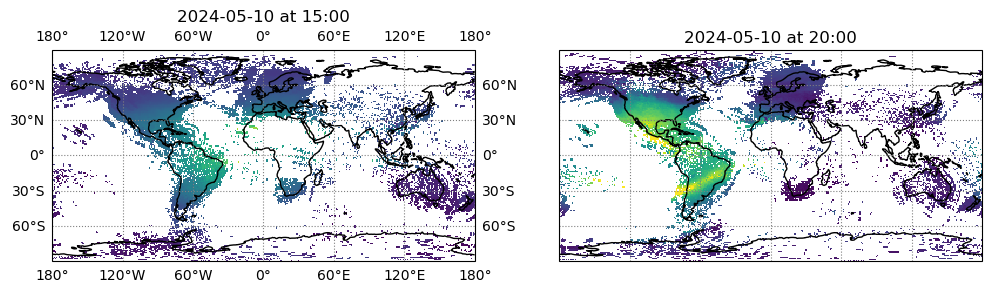

In [100]:
date = '2024-05-10'
time1 = '15:00'
time2 = '20:00'
fig, ax = plt.subplots(1,2, figsize=(12,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax1, ax2 = ax

# MAY 10th
ax1.coastlines()
cs = ax1.pcolormesh(ds_10th.tec.sel(time=f'{date}T{time1}:00').glon, 
               ds_10th.tec.sel(time=f'{date}T{time1}:00').gdlat, 
               ds_10th.tec.sel(time=f'{date}T{time1}:00').values,
                vmin=0, vmax=110,
               transform=ccrs.PlateCarree())
ax1.gridlines(draw_labels=True, linestyle=':', color='grey')
ax1.set_title(f'{date} at {time1}')

ax2.coastlines()
cs = ax2.pcolormesh(ds_10th.tec.sel(time=f'{date}T{time2}:00').glon, 
               ds_10th.tec.sel(time=f'{date}T{time2}:00').gdlat, 
               ds_10th.tec.sel(time=f'{date}T{time2}:00').values,
                vmin=0, vmax=110,
               transform=ccrs.PlateCarree())
ax2.gridlines(draw_labels=False, linestyle=':', color='grey')
ax2.set_title(f'{date} at {time2}')